# Homework 5

## Question 1

### Part (a)

This section computes the constant-model market impact curve for ZNH4 over selected February 2024 trading days.

The workflow is:
- connect to the kdb server
- for each date, as-of join trades with quotes to get midpoint at each trade time
- map trade aggressor flags to +1 and -1
- compute signed midpoint changes for lags 1 to 50 and aggregate across days
- average by lag and plot the resulting impact curve

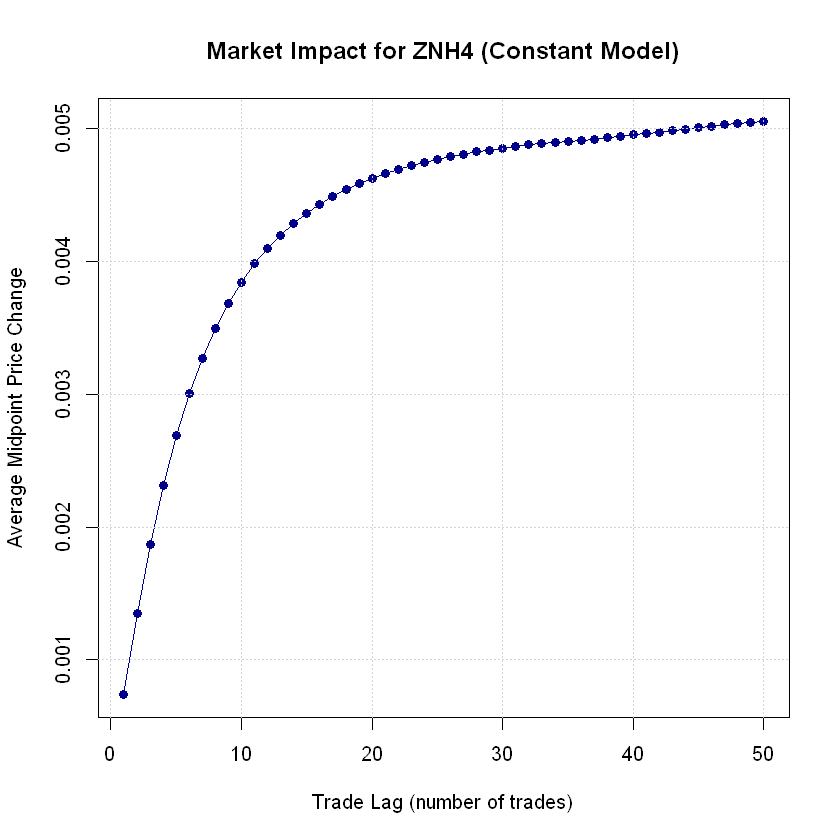

In [13]:
library(rkdb)

host <- "hfm.princeton.edu"
port <- 6007

h <- open_connection(host, port)

sym <- "ZNH4"
dates <- c("2024.02.05", "2024.02.06", "2024.02.07", "2024.02.08", "2024.02.09",
           "2024.02.12", "2024.02.13", "2024.02.14", "2024.02.15", "2024.02.16",
           "2024.02.20", "2024.02.21", "2024.02.22", "2024.02.23")

max_lag <- 50
total_impact <- numeric(max_lag)
total_count <- numeric(max_lag)

for (d in dates) {
  q_str <- paste0(
    "aj[`time; ",
    "(select time, aggr from trade where date=", d, ", sym=`", sym, "); ",
    "(select time, midpoint: 0.5*(bid+ask) from quote where date=", d, ", sym=`", sym, ")]"
  )
  
  df <- execute(h, q_str)
  
  if (nrow(df) > max_lag) {
    df$sign <- NA
    df$sign[df$aggr == "B"] <- 1
    df$sign[df$aggr == "S"] <- -1
    
    for (k in 1:max_lag) {
      idx <- which(!is.na(df$sign))
      idx <- idx[idx + k <= nrow(df)]
      
      impact_k <- df$sign[idx] * (df$midpoint[idx + k] - df$midpoint[idx])
      valid_impacts <- impact_k[!is.na(impact_k)]
      
      total_impact[k] <- total_impact[k] + sum(valid_impacts)
      total_count[k] <- total_count[k] + length(valid_impacts)
    }
  }
}

average_impact <- total_impact / total_count

plot(1:max_lag, average_impact, type = "o", pch = 16, col = "darkblue",
     xlab = "Trade Lag (number of trades)", 
     ylab = "Average Midpoint Price Change",
     main = paste("Market Impact for", sym, "(Constant Model)"))
grid()

### Part (b) Market Impact by Trade Size

To evaluate the importance of trade size, we modify our previous query to also extract the size of each trade. We then compute the median trade size for each day. 

Trades are split into two categories: those strictly greater than the median size, and those less than or equal to the median size. We calculate the forward price change for both subsets independently and plot them on the same graph to visually inspect if larger trades carry more information and therefore cause a larger permanent market impact.

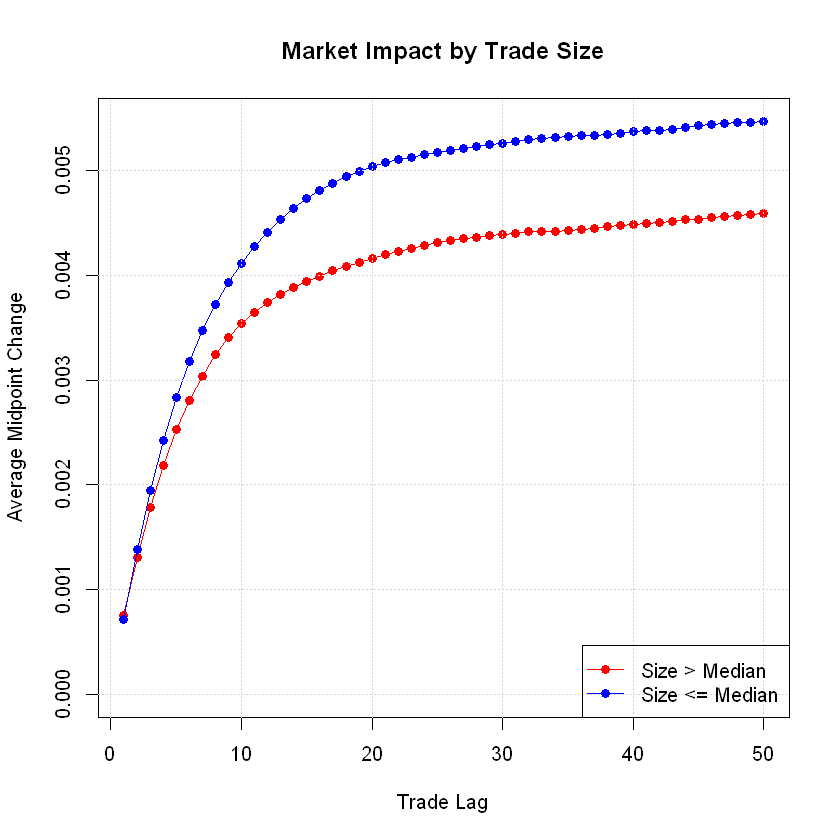

In [15]:
max_lag <- 50
impact_small <- numeric(max_lag)
count_small <- numeric(max_lag)
impact_large <- numeric(max_lag)
count_large <- numeric(max_lag)

for (d in dates) {
  q_str <- paste0(
    "aj[`time; ",
    "(select time, size:siz, aggr from trade where date=", d, ", sym=`", sym, "); ",
    "(select time, midpoint: 0.5*(bid+ask) from quote where date=", d, ", sym=`", sym, ")]"
  )
  
  df <- execute(h, q_str)
  
  if (nrow(df) > max_lag) {
    df$sign <- NA
    df$sign[df$aggr == "B"] <- 1
    df$sign[df$aggr == "S"] <- -1
    
    med_size <- median(df$size, na.rm = TRUE)
    
    idx_valid <- which(!is.na(df$sign))
    idx_small <- idx_valid[df$size[idx_valid] <= med_size]
    idx_large <- idx_valid[df$size[idx_valid] > med_size]
    
    for (k in 1:max_lag) {
      idx_s_k <- idx_small[idx_small + k <= nrow(df)]
      imp_s <- df$sign[idx_s_k] * (df$midpoint[idx_s_k + k] - df$midpoint[idx_s_k])
      valid_s <- imp_s[!is.na(imp_s)]
      impact_small[k] <- impact_small[k] + sum(valid_s)
      count_small[k] <- count_small[k] + length(valid_s)
      
      idx_l_k <- idx_large[idx_large + k <= nrow(df)]
      imp_l <- df$sign[idx_l_k] * (df$midpoint[idx_l_k + k] - df$midpoint[idx_l_k])
      valid_l <- imp_l[!is.na(imp_l)]
      impact_large[k] <- impact_large[k] + sum(valid_l)
      count_large[k] <- count_large[k] + length(valid_l)
    }
  }
}

avg_impact_small <- impact_small / count_small
avg_impact_large <- impact_large / count_large

plot(1:max_lag, avg_impact_large, type = "o", pch = 16, col = "red",
     xlab = "Trade Lag", ylab = "Average Midpoint Change",
     main = "Market Impact by Trade Size", ylim = range(c(avg_impact_small, avg_impact_large, 0)))
lines(1:max_lag, avg_impact_small, type = "o", pch = 16, col = "blue")
grid()
legend("bottomright", legend = c("Size > Median", "Size <= Median"), 
       col = c("red", "blue"), lty = 1, pch = 16)

### 1(c) Market Impact by Quote Size (Depth)

To test if trades sent into deeper markets have a smaller impact, we need to separate trades based on the quote size on the side of the market they executed against. 

A market buy order (aggr = B) executes against the ask, so the relevant depth is the ask size (asiz). A market sell order (aggr = S) executes against the bid, so the relevant depth is the bid size (bsiz). We extract these sizes, find the daily median depth, and split our trades into deep (above median) and shallow (below or equal to median) categories before computing the forward impact.

[1] 0

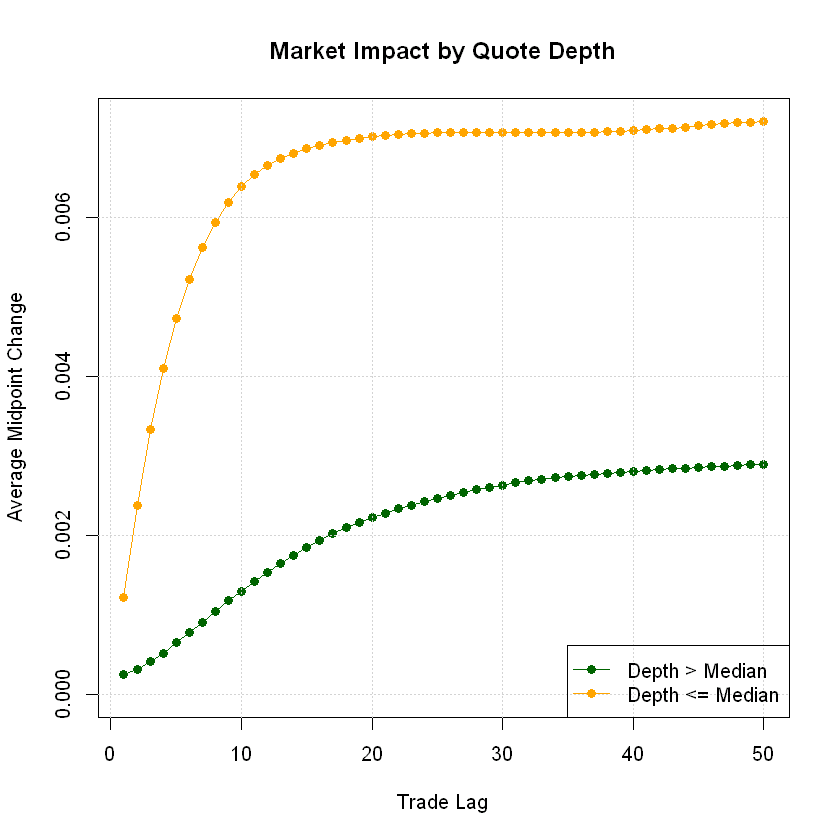

In [16]:
max_lag <- 50
impact_shallow <- numeric(max_lag)
count_shallow <- numeric(max_lag)
impact_deep <- numeric(max_lag)
count_deep <- numeric(max_lag)

for (d in dates) {
  q_str <- paste0(
    "aj[`time; ",
    "(select time, aggr from trade where date=", d, ", sym=`", sym, "); ",
    "(select time, bsiz, asiz, midpoint: 0.5*(bid+ask) from quote where date=", d, ", sym=`", sym, ")]"
  )
  
  df <- execute(h, q_str)
  
  if (nrow(df) > max_lag) {
    df$sign <- NA
    df$sign[df$aggr == "B"] <- 1
    df$sign[df$aggr == "S"] <- -1
    
    df$quote_depth <- NA
    df$quote_depth[df$aggr == "B"] <- df$asiz[df$aggr == "B"]
    df$quote_depth[df$aggr == "S"] <- df$bsiz[df$aggr == "S"]
    
    med_depth <- median(df$quote_depth, na.rm = TRUE)
    
    idx_valid <- which(!is.na(df$sign) & !is.na(df$quote_depth))
    idx_shallow <- idx_valid[df$quote_depth[idx_valid] <= med_depth]
    idx_deep <- idx_valid[df$quote_depth[idx_valid] > med_depth]
    
    for (k in 1:max_lag) {
      idx_s_k <- idx_shallow[idx_shallow + k <= nrow(df)]
      imp_s <- df$sign[idx_s_k] * (df$midpoint[idx_s_k + k] - df$midpoint[idx_s_k])
      valid_s <- imp_s[!is.na(imp_s)]
      impact_shallow[k] <- impact_shallow[k] + sum(valid_s)
      count_shallow[k] <- count_shallow[k] + length(valid_s)
      
      idx_d_k <- idx_deep[idx_deep + k <= nrow(df)]
      imp_d <- df$sign[idx_d_k] * (df$midpoint[idx_d_k + k] - df$midpoint[idx_d_k])
      valid_d <- imp_d[!is.na(imp_d)]
      impact_deep[k] <- impact_deep[k] + sum(valid_d)
      count_deep[k] <- count_deep[k] + length(valid_d)
    }
  }
}

avg_impact_shallow <- impact_shallow / count_shallow
avg_impact_deep <- impact_deep / count_deep

plot(1:max_lag, avg_impact_deep, type = "o", pch = 16, col = "darkgreen",
     xlab = "Trade Lag", ylab = "Average Midpoint Change",
     main = "Market Impact by Quote Depth", ylim = range(c(avg_impact_shallow, avg_impact_deep, 0)))
lines(1:max_lag, avg_impact_shallow, type = "o", pch = 16, col = "orange")
grid()
legend("bottomright", legend = c("Depth > Median", "Depth <= Median"),
       col = c("darkgreen", "orange"), lty = 1, pch = 16)

## Question 2. Intraday Liquidity Curve

Part (a) For each minute on each date, extract 1-minute bid-ask midpoint price samples p, using aj [], and take the differences $\Delta p$.

For our active symbol, we will use the S&P 500 E-mini futures contract (`ESH4`). We create a regular 1-minute time grid from 07:00 to 16:00. Using an as-of join (`aj`) in Q, we extract the most recent bid and ask quotes at exactly each minute mark, compute the midpoint $p$, and calculate the minute-by-minute price differences $\Delta p$.

In [18]:
sym <- "ESH4"
dates <- c("2024.02.05", "2024.02.06", "2024.02.07", "2024.02.08", "2024.02.09",
           "2024.02.12", "2024.02.13", "2024.02.14", "2024.02.15", "2024.02.16",
           "2024.02.20", "2024.02.21", "2024.02.22", "2024.02.23")

dt <- 60
nt <- (16 - 7) * 60 + 1 

results_2a <- list()

for (d in dates) {
  
  q_str <- paste0(
    "select time, midpoint from aj[`time; ",
    "([] time: 0D07:00:00 + ", dt, " * 1000000000 * til ", nt, "); ",
    "(select time, midpoint: 0.5*(bid+ask) from quote where date=", d, ", sym=`", sym, ")] ",
    "where not null midpoint"
  )
  
  df <- execute(h, q_str)
  
  if(nrow(df) > 1) {
    df$date <- as.Date(d, format="%Y.%m.%d")
    df$dp <- c(NA, diff(df$midpoint))
    results_2a[[d]] <- df
  }
}

df_prices <- do.call(rbind, results_2a)

print(utils::head(df_prices))

                       time midpoint       date     dp
2024.02.05.1 25200000000000 497412.5 2024-02-05     NA
2024.02.05.2 25260000000000 497437.5 2024-02-05   25.0
2024.02.05.3 25320000000000 497287.5 2024-02-05 -150.0
2024.02.05.4 25380000000000 497375.0 2024-02-05   87.5
2024.02.05.5 25440000000000 497412.5 2024-02-05   37.5
2024.02.05.6 25500000000000 497312.5 2024-02-05 -100.0


### Part (b) Net Traded Volume per Minute

For each minute, extract the net traded volume v: buy volume $v_B$ minus sell volume $v_S$ For a product like ESH4 that has a small amount of implied trading, it will be enough to use the aggr tag; for an energy or agricultural product you will need to match the bid and ask.

To compute the net traded volume for each minute, we query the `trade` table. We use Q's `xbar` operator to bin the trade timestamps into exactly 1-minute intervals, which will align perfectly with our price grid from part (a). We then sum the sizes for buy trades (`aggr=\`B`) and sell trades (`aggr=\`S`) within each minute and take the difference.

In [22]:
results_2b <- list()

for (d in dates) {
  
  q_str <- paste0(
    "select time, v: vB - vS from ",
    "(select vB: sum siz where aggr=`B, vS: sum siz where aggr=`S by time: 0D00:01:00 xbar time ",
    "from trade where date=", d, ", sym=`", sym, ", time within (0D07:00:00; 0D16:00:00))"
  )
  
  df <- execute(h, q_str)
  
  if (nrow(df) > 0) {
    df$date <- as.Date(d, format = "%Y.%m.%d")
    df$v[is.na(df$v)] <- 0
    results_2b[[d]] <- df
  }
}

df_volume <- do.call(rbind, results_2b)
close_connection(h)

print(utils::head(df_volume))

[1] 0

                       time    v       date
2024.02.05.1 25200000000000  -46 2024-02-05
2024.02.05.2 25260000000000 -114 2024-02-05
2024.02.05.3 25320000000000  108 2024-02-05
2024.02.05.4 25380000000000   -6 2024-02-05
2024.02.05.5 25440000000000 -136 2024-02-05
2024.02.05.6 25500000000000  -79 2024-02-05


### Part (c) Linear Regression for Illiquidity ($\lambda$)

For any particular time period, do a linear regression of $\Delta p$ against v, with zero intercept so $\Delta p=\lambda v$. The coefficient $\lambda$ is an illiquidity as in Kyle's model.

We merge the 1-minute price differences ($\Delta p$) from part (a) and the net volume ($v$) from part (b) by their timestamps. Then, we perform a linear regression without an intercept (`dp ~ v - 1`) to estimate Kyle's lambda ($\lambda$), which represents the permanent price impact per unit of net volume traded.


Call:
lm(formula = dp ~ v - 1, data = df_clean)

Residuals:
     Min       1Q   Median       3Q      Max 
-2317.73   -51.42     1.22    59.16  1124.13 

Coefficients:
  Estimate Std. Error t value Pr(>|t|)    
v 0.021625   0.002601   8.313   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 122.6 on 7545 degrees of freedom
Multiple R-squared:  0.009076,	Adjusted R-squared:  0.008945 
F-statistic: 69.11 on 1 and 7545 DF,  p-value: < 2.2e-16



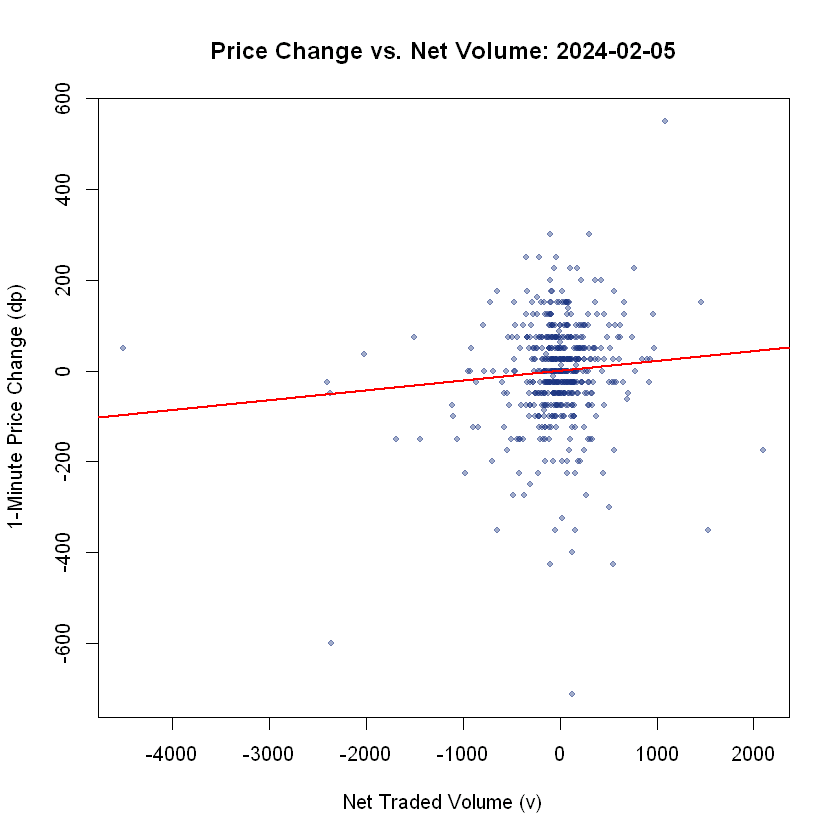

In [24]:
df_merged <- merge(df_prices, df_volume, by = c("date", "time"))

df_merged$dp <- as.numeric(df_merged$dp)
df_merged$v <- as.numeric(df_merged$v)

df_clean <- subset(df_merged, is.finite(dp) & is.finite(v))

if (nrow(df_clean) == 0) {
  stop("No valid rows after filtering finite dp and v for regression.")
}

model_lambda <- lm(dp ~ v - 1, data = df_clean)

print(summary(model_lambda))

target_date <- unique(df_clean$date)[1]
df_plot <- subset(df_clean, date == target_date)

plot(df_plot$v, df_plot$dp,
     main = paste("Price Change vs. Net Volume:", target_date),
     xlab = "Net Traded Volume (v)",
     ylab = "1-Minute Price Change (dp)",
     pch = 20, col = rgb(0.1, 0.2, 0.5, 0.4))

abline(a = 0, b = coef(model_lambda)[1], col = "red", lwd = 2)

### Part (d) Intraday Liquidity Curve across the Day

For the final step, we repeat the linear regression of 1-minute price changes ($\Delta p$) against net volume ($v$) for each hour of the trading day (07:00 to 15:00), using the data aggregated across our entire date range. 

By plotting the resulting slope coefficients ($\lambda$) for each hour, we produce the intraday illiquidity curve. A higher $\lambda$ indicates lower liquidity (higher price impact per unit of volume), which typically exhibits a U-shape or reverse J-shape, with liquidity being lowest (highest $\lambda$) at the open and close of the market.

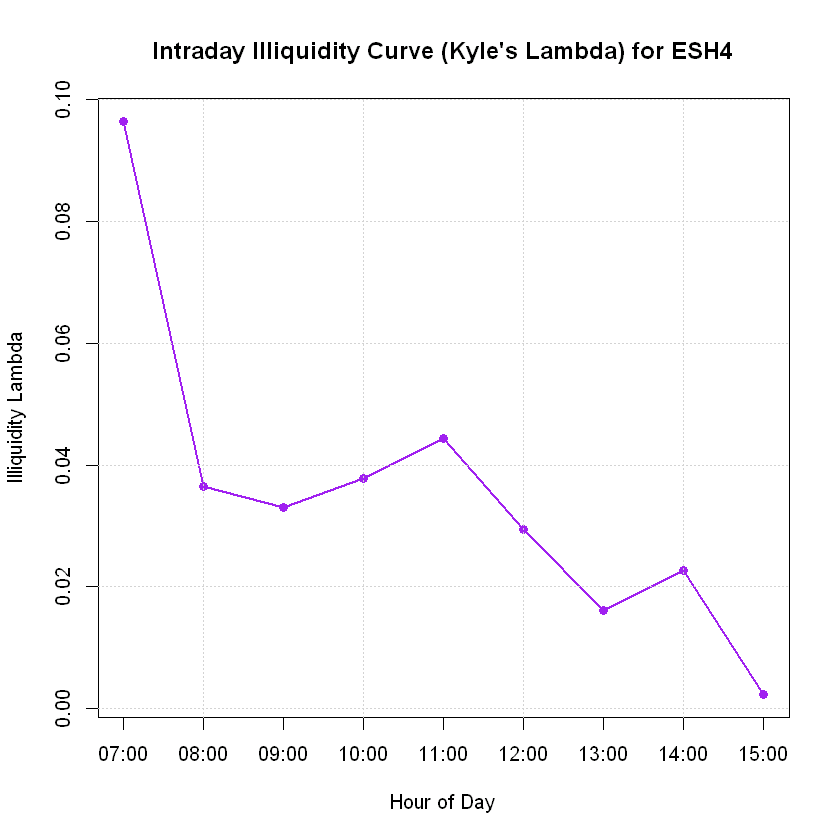

In [25]:
df_clean$hour <- floor(as.numeric(df_clean$time) / (1e9 * 60 * 60))

hours <- 7:15
lambdas <- numeric(length(hours))

for (i in seq_along(hours)) {
  df_hour <- subset(df_clean, hour == hours[i])
  
  if (nrow(df_hour) > 10) {
    model_h <- lm(dp ~ v - 1, data = df_hour)
    lambdas[i] <- coef(model_h)[1]
  } else {
    lambdas[i] <- NA
  }
}

df_lambda <- data.frame(hour = hours, lambda = lambdas)

plot(df_lambda$hour, df_lambda$lambda, type = "o", pch = 16, col = "purple", lwd = 2,
     main = paste("Intraday Illiquidity Curve (Kyle's Lambda) for", sym),
     xlab = "Hour of Day", 
     ylab = "Illiquidity Lambda",
     axes = FALSE)

axis(1, at = hours, labels = paste0(sprintf("%02d", hours), ":00"))
axis(2)
box()
grid()